In [1]:
#! pip install spacy

In [2]:
#! python -m spacy download en_core_web_sm

In [3]:
import glob
import json
from sklearn import model_selection
import spacy  # for tokenizer
import torch
import torchvision
import os
import re
import json

In [4]:
spacy_eng = spacy.load('en_core_web_sm')

In [5]:
data_dir = os.path.join(os.getcwd(), 'Ex14', 'data')
caption_dir = os.path.join(data_dir, 'archive', 'captions.txt')
image_dir = os.path.join(data_dir, 'archive', 'Images')

In [6]:
image_file_name = [name for name in glob.glob(os.path.join(image_dir,'*'))]
len(image_file_name)

8091

In [7]:
with open (caption_dir, 'r') as f:
    rows = f.read()
    rows = rows.split('\n')[1:-1] # dòng đầu là tên cột dòng cuối không có ký tự gì
len(rows)

40455

# Captions.txt:
* dòng đầu tiên là tên cột, dòng cuối không có gì
* mỗi dòng là tên img và caption, được phân tách bởi dấu phẩy ngay sau .jpg
* trong captions có thể có nhiều dấu phẩy
* một số caption có bắt đầu và kết thúc bởi " "

In [8]:
def make_data(txt_path = data_dir):
    img_names = []
    captions = []
    with open(caption_dir, 'r') as f:
        rows = f.read()
        rows = rows.split('\n')[1:-1]
    for row in rows:
        row = re.split(r'(?<=jpg),', row)
        img_names.append(row[0])
        if re.search(f'"', row[1]):
            captions.append(row[1].split('"')[1])
        else:
            captions.append(row[1])
    return img_names, captions
make_data()

(['1000268201_693b08cb0e.jpg',
  '1000268201_693b08cb0e.jpg',
  '1000268201_693b08cb0e.jpg',
  '1000268201_693b08cb0e.jpg',
  '1000268201_693b08cb0e.jpg',
  '1001773457_577c3a7d70.jpg',
  '1001773457_577c3a7d70.jpg',
  '1001773457_577c3a7d70.jpg',
  '1001773457_577c3a7d70.jpg',
  '1001773457_577c3a7d70.jpg',
  '1002674143_1b742ab4b8.jpg',
  '1002674143_1b742ab4b8.jpg',
  '1002674143_1b742ab4b8.jpg',
  '1002674143_1b742ab4b8.jpg',
  '1002674143_1b742ab4b8.jpg',
  '1003163366_44323f5815.jpg',
  '1003163366_44323f5815.jpg',
  '1003163366_44323f5815.jpg',
  '1003163366_44323f5815.jpg',
  '1003163366_44323f5815.jpg',
  '1007129816_e794419615.jpg',
  '1007129816_e794419615.jpg',
  '1007129816_e794419615.jpg',
  '1007129816_e794419615.jpg',
  '1007129816_e794419615.jpg',
  '1007320043_627395c3d8.jpg',
  '1007320043_627395c3d8.jpg',
  '1007320043_627395c3d8.jpg',
  '1007320043_627395c3d8.jpg',
  '1007320043_627395c3d8.jpg',
  '1009434119_febe49276a.jpg',
  '1009434119_febe49276a.jpg',
  '10094

In [9]:
def split_data(img_names, targets):
    X, y = img_names, targets
    img_names_train, img_names_test, captions_train, captions_test = model_selection.train_test_split(X, y, test_size = 0.05, random_state = 36)
    img_names_train, img_names_val, captions_train, captions_val = model_selection.train_test_split(img_names_train, captions_train, test_size = 0.05, random_state = 36)
    return img_names_train,captions_train,img_names_val,captions_val,img_names_test,captions_test

In [10]:
def write_json(data, data_path):
    with open(data_path, 'w') as f:
        json.dump(data, f)

In [11]:
def read_json(data_path):
    with open(data_path, 'r') as f:
        content = json.load(f)
    return content

In [12]:
spacy_eng = spacy.load("en_core_web_sm")

# đầu ra của list(spacy_eng.tokenizer(text)) là 1 list của các đối tượng doc, nếu dùng để trực tiếp so sánh với 1 string thì kết quả là false cần chuyển từ token sang string
def tokenizer_eng(text):
    return [i.text for i in list(spacy_eng.tokenizer(text))]

class Vocab:
    def __init__(self, captions, freq_threshold):
        self.captions = captions
        self.freq_threshold = freq_threshold
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"} # index to string
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3} # string to index
    def get_vocab(self):
        word2fre = {}
        idx = 4
        self.max_length = 0
        for caption in self.captions:
            for i, word in enumerate(tokenizer_eng(caption)):
                if word not in word2fre:
                    word2fre[word] = 1
                else:
                    word2fre[word] += 1
                if word2fre[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1
            if i+1 > self.max_length:
                self.max_length = i + 1
    
    # max length để lưu độ dài đoạn có số token nhiều nhất trong caption
    # token nào đến ngưỡng trước thì được cho vào itos, stoi, vẫn tiếp tục cộng dồng fre của token đó
    # token nào có số lần xuất hiện thếp hơn ngưỡng thì có thể được coi là stopword

In [13]:
def numericalize(text, stoi):
    tokenized_text = tokenizer_eng(text)
    vector = [stoi[token] if token in stoi else stoi["<UNK>"] for token in tokenized_text]
    return vector

In [14]:
def clip_gradient(optimizer, grad_clip): # grad_clip là biên để clap
    for group in optimizer.param_groups:
        for param in group['params']:
            if param.grad is not None:
                param.grad.data.clamp(-grad_clip, grad_clip)

In [15]:
os.makedirs(os.path.join(os.getcwd(), 'Ex14', 'model'), exist_ok = True)
model_save_path = os.path.join(os.getcwd(), 'Ex14', 'model')
def save_checkpoint(epoch, encoder, decoder, encoder_optimizer, decoder_optimizer, filename, model_save_path = model_save_path):
    state = {'epoch': epoch,       
             'encoder': encoder,
             'decoder': decoder,
             'encoder_optimizer': encoder_optimizer,
             'decoder_optimizer': decoder_optimizer}
    file_dir = os.path.join(model_save_path, f'{filename}.tar')
    torch.save(state, file_dir)


In [16]:
img_names, captions = make_data()
img_names_train,captions_train,img_names_val,captions_val,img_names_test,captions_test = split_data(img_names, captions)

In [17]:
os.makedirs(os.path.join(data_dir, 'json'), exist_ok = True)
itos_dir = os.path.join(data_dir, 'json', 'itos_file.json')
stoi_dir = os.path.join(data_dir, 'json', 'stoi_file.json')

vocab = Vocab(captions_train, freq_threshold = 3)
vocab.get_vocab()
write_json(vocab.itos, itos_dir)
write_json(vocab.stoi, stoi_dir)

In [18]:
stoi = read_json(stoi_dir)
print(numericalize('Hello i am cuong', stoi))

[2907, 2421, 3, 3]


In [19]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import cv2
import numpy as np

In [20]:
batch_size = None
num_workers = 4
max_len = 45

In [21]:
# 1 đối tượng dataset thông thường cần phải có phương thức len và getitem
# cần len để khi sử dụng với data loader data loader biết cần gen ra index trong khoảng từ bao nhiêu đến bao nhiêu và quan trọng cho việc tính số lượng batch trong 1 epoch 
# cần getitem để dataloader sử dụng khi cần load dữ liệu ( sau khi đã được gen index ) 
class IMDataset(Dataset):
    def __init__(self, img_names, captions, transform = None):
        self.img_names = img_names
        self.captions = captions
        self.transform = transform
        self.itos = read_json(itos_dir)
        self.stoi = read_json(stoi_dir)
    def __len__(self):
        return len(self.img_names)
    def encode(self, c):
        c = numericalize(c, self.stoi)
        self.c_len = len(c)
        # encode thì cần có start of sentence, và end of sentence và các token padding đằng sau nếu không đủ độ dài
        enc = [1] + c + [2] + [0] * (max_len - len(c))
        return enc
    def __getitem__(self, index):
        caption = self.captions[index]
        img_name = self.img_names[index]
        img_id_dir = os.path.join(image_dir, f'{img_name}')
        image = cv2.imread(img_id_dir)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # OpenCV đọc BGR, matplotlib mong RGB
        image = cv2.resize(image, (256,256))
        image = torch.tensor(image, dtype = torch.float32)
        image = image/255
        # lúc này image đang có dạng h*w*channel cần chuyển về c*h*w
        image = image.permute(2,0,1)
        if self.transform is not None:
            image = self.transform(image)
        caption_encoding = self.encode(caption) 
        caplen = self.c_len + 2 # thêm 2 token bắt đầu và kết thúc, độ dài thật không tính các padding
        return image, torch.LongTensor(caption_encoding), torch.LongTensor([caplen]), img_name


In [22]:
import random
import matplotlib.pyplot as plt
import numpy as np

transform = transforms.Compose([
    transforms.Resize((224,224))
])

dataset = IMDataset(img_names_test, captions_test, transform = transform)
loader = DataLoader(
    dataset = dataset,
    batch_size = 64,
    num_workers = 0
)
imgs, captions, _ , _ = next(iter(loader))

In [23]:
imgs.shape

torch.Size([64, 3, 224, 224])

In [24]:
captions.shape

torch.Size([64, 47])

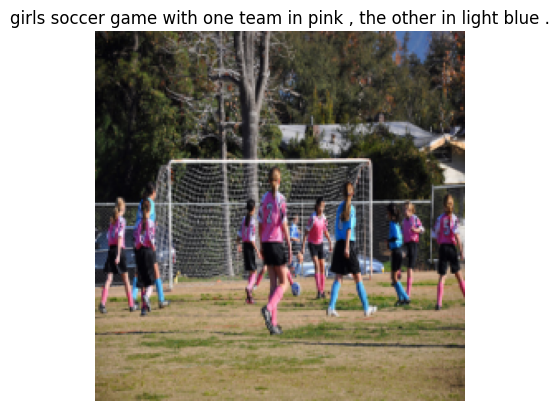

In [25]:
itos = read_json(itos_dir)
def plot(imgs, captions):
    idx = random.choice(range(len(imgs)))
    img = imgs[idx]
    caption = captions[idx].detach().cpu().numpy() # caption lúc này đang là 1 loạt các stoi
    caption = ' '.join(itos[str(x)] for x in caption if x!=0 and x!=1 and x!=2 and x!=3 and x!=4)
    img = img.permute(1,2,0).detach().cpu().numpy()
    plt.axis('off')
    plt.imshow(img)
    plt.title(caption)
    plt.show()
plot(imgs, captions)

# RESNET 101
* 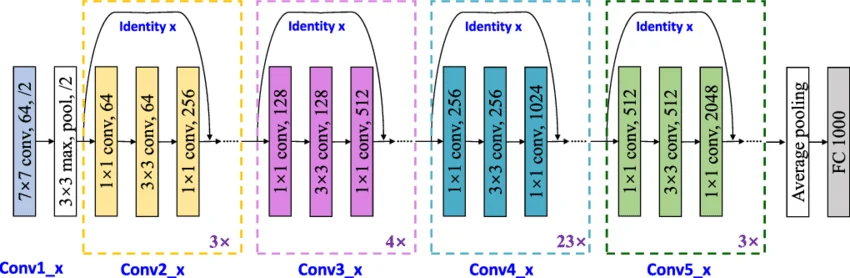

pipeline bài toán:
* 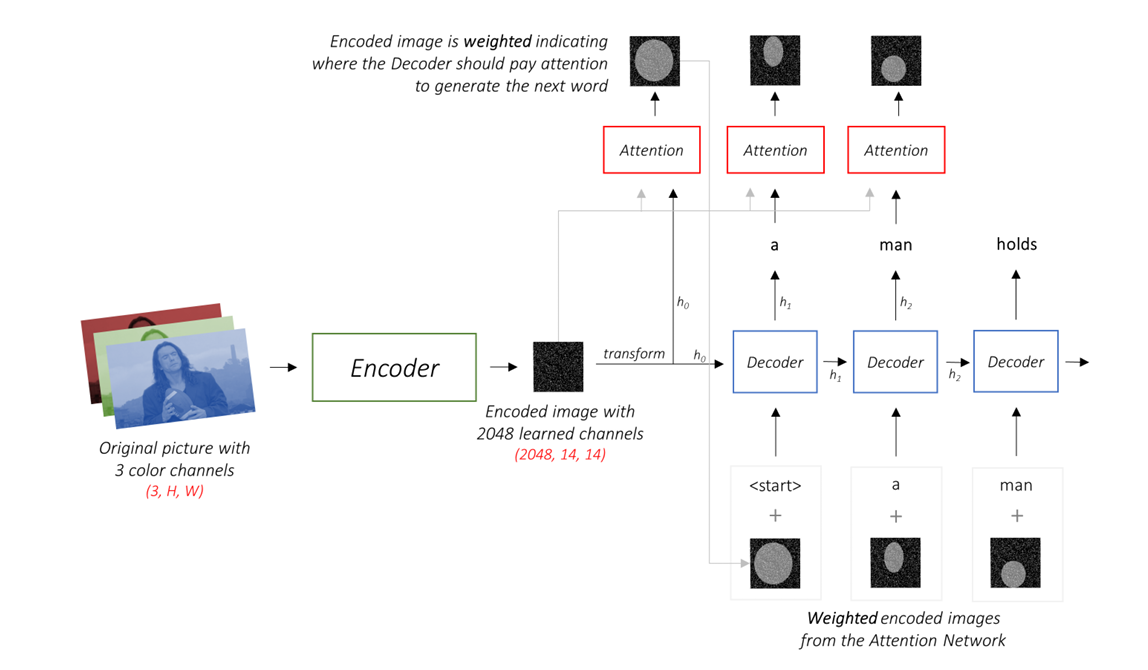

Theo t thì pipeline sơ lược là như sau:
* đầu tiên là encode ảnh để lấy feature map
* sau đó sử dụng kiến trúc rnn or lstm. áp dụng cơ chế attention đối với trạng thái ẩn hn hiện tại và feature map, đầu ra chính là vector của 1 phần ảnh cần chú ý, ta lấy output này concat với embedding của từ được dự đoán trước đó, lấy tổng này và hidden state để làm đầu vào của time step tiếp theo

In [26]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [27]:
import torch.nn as nn
class Encoder(nn.Module):
    def __init__(self, encoded_image_size = 14):
        super(Encoder, self).__init__()
        self.enc_image_size = encoded_image_size
        resnet = torchvision.models.resnet101(pretrained = True)
        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules) # unpack list module vì seq không nhận nguyên 1 list
        self.adaptive_pool = nn.AdaptiveAvgPool2d((14,14))
        self.fine_tune()
    
    def forward(self, images): # b*c*h*w
        out = self.resnet(images)
        out = self.adaptive_pool(out)
        out = out.permute(0,2,3,1) # b*h*w*c
        # ta sẽ có tất cả b batch và h*w ô pixel để xét độ quan trọng về vị trí, ý đồ là vậy
        # nếu giữ nguyên chiều thì sẽ là xét trên channels (chỉ ảnh hưởng đến màu sắc không có ý nghĩa mấy)
        return out

    # fine tune deactive theo dõi grad của các lớp không cần
    def fine_tune(self, fine_tune = True):
        for p in self.resnet.parameters():
            p.requires_grad = False
        for c in list(self.restnet.children())[5:]:
            for p in c.parameters():
                for p in c.parameters():
                    p.requires_grad = fine_tune

In [28]:
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim): #encoder dim là số chiều của 1 pixel trong trường hợp này là số lượng channel cuối, decoder dim là chiều của hidden state
        super(Attention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        # mục đích của 2 att là để chuyển en và de về cùng số chiều
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim = 1)

    def forward(self, encoder_out, decoder_hidden):
        # tính toán attention của hidden state bên decoder và đầu ra của encoder
        att1 = self.encoder_att(encoder_out)  # b*h*w*c*c*att_dim = b*h*w*att_dim = b*pixel_num*att_dim
        att2 = self.decoder_att(decoder_hidden) # b*att_dim
        att = self.full_att(self.relu(att1 + att2.unsqueeze(1))).squeeze(2)
        # b*pixel_num*att_dim + b*1*att_dim = b*pixel*att_dim, nhân với attention_dim*1, unqueeze this shit ta có b*pixel
        alpha = self.softmax(att)
        attention_weighted_encoding = (encoder_out * alpha.unsqueeze(2)).sum(dim=1) # nhân từng phần tử
        # batch*pixel_num*c lấy dim 1 thành batch*c c trong bài này là 2048
        return attention_weighted_encoding, alpha

# 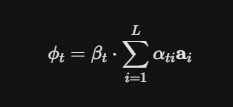
* ở decoder ta biết là cần concat embed của token và phần output attention của hidden state và ảnh, tuy nhiên liệu ta nên thêm bao nhiêu phần ảnh vào thì không rõ
* ta cần 1 đại lượng beta để làm hệ số kiểm soát lượng thông tin liên quan đến ảnh có thể được thêm vào

In [29]:
class DecoderWithAttention(nn.Module):
    def __init__(self, attention_dim, embed_dim, decoder_dim, vocab_size, encoder_dim=2048, dropout=0.5):
        super(DecoderWithAttention, self).__init__()
        self.encoder_dim = encoder_dim
        self.attention_dim = attention_dim
        self.embed_dim = embed_dim
        self.decoder_dim = decoder_dim
        self.vocab_size = vocab_size
        self.dropout = dropout
        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)  
        self.embedding = nn.Embedding(vocab_size, embed_dim)  # embedding layer, trainable, hoạt động theo kiểu look up
        self.dropout = nn.Dropout(p=self.dropout)
        self.decode_step = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim, bias=True) # chỉ duy nhất 1 cell lstm
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)
        self.f_beta = nn.Linear(decoder_dim, encoder_dim)
        self.sigmoid = nn.Sigmoid()
        self.fc = nn.Linear(decoder_dim, vocab_size)
        self.init_weights()
    
    def init_weights(self):
        self.embedding.weight.data.uniform_(-0.1, 0.1) # sử dụng inplace để trực tiếp sửa đổi
        self.fc.bias.data.fill_(0)
        self.fc.weight.data.uniform_(-0.1, 0.1)
    
    def load_pretrained_embeddings(self, embeddings):
        self.embedding.weight = nn.Parameter(embeddings)
    
    def fine_tune_embeddings(self, fine_tune = True):
        for p in self.embedding.parameters():
            p.requires_grad = fine_tune
    
    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder_out)  # (batch_size, decoder_dim)
        c = self.init_c(mean_encoder_out)
        return h, c
    
    def forward(self, encoder_out, encoded_captions, caption_lengths):
        batch_size = encoder_out.size(0)
        encoder_dim = encoder_out.size(-1)
        vocab_size = self.vocab_size

        #flatten, từ batch*h*w*c thành batch*pixel_num*c
        encoder_out = encoder_out.view(batch_size, -1, encoder_dim)
        num_pixels = encoder_out.size(1)

        #sort input data theo chiều giảm dần length
        # caption len có dạng batch*1
        # sort trả về tensor đã được sort và index cùng lúc dưới dạng tuple
        caption_lengths, sort_ind = caption_lengths.squeeze(1).sort(dim=0, descending=True)
        encoder_out = encoder_out[sort_ind]
        encoded_captions = encoded_captions[sort_ind]

        # embed
        embeddings = self.embedding(encoded_captions)

        # init lstm state
        h, c = self.init_hidden_state(encoder_out)
        decode_lengths = (caption_lengths - 1).tolist() # số time step
        predictions = torch.zeros(batch_size, max(decode_lengths), vocab_size).to(device)
        alphas = torch.zeros(batch_size, max(decode_lengths), num_pixels).to(device) # điểm số của các pixel tại các bước thời gian

        # ở mỗi timestep tạo ra từ mới dựa trên attention weight và từ trước đó
        for t in range(max(decode_lengths)): 
            batch_size_t = sum([l > t for l in decode_lengths]) # số lượng các samples có độ dài lớn hơn t
            # idx bắt đầu từ 0 nên l>t không có dấu =
            # mục đích của việc sort các caption len để thuận tiện việc xác định các batch có chiều dài thỏa mãn, nếu không sort thì mỗi vòng lặp lại tốn thêm o(n) để tìm các batch t/m
            attention_weighted_encoding, alpha = self.attention(encoder_out[:batch_size_t], h[:batch_size_t])
            gate = self.sigmoid(self.f_beta(h[:batch_size_t])) # batch_t * encoder_dim, khoảng (0,1)
            # nhân gate với attention_w_e để kiểm soát lượng thông tin của ảnh được cho vào input
            attention_weighted_encoding = gate * attention_weighted_encoding
            h, c = self.decode_step(
                torch.cat([embeddings[:batch_size_t, t, :], attention_weighted_encoding], dim = 1),
                (h[:batch_size_t], c[:batch_size_t])
            )
            preds = self.fc(self.dropout(h))
            predictions[:batch_size_t, t, :] = preds
            alphas[:batch_size_t, t, :] = alpha # alpha cho biết điểm số của các pixel với từng bước thời gian cụ thể, có thể dùng để tính loss ở các mốc thời gian cụ thể theo kiểu crossentropy
        return predictions, encoded_captions, decode_lengths, alphas, sort_ind

In [30]:
alpha_c = 1
encoder_lr = 1e-4  
decoder_lr = 4e-4 
num_epochs = 10

emb_dim = 512  # dimension của word embeddings
attention_dim = 512  # dimension của attention linear layers
decoder_dim = 512  # dimension của decoder RNN
dropout = 0.5

save_log = os.path.join(data_dir, 'log', 'log.csv')

In [40]:
from tqdm import tqdm
from torch.nn.utils.rnn import pack_padded_sequence
import pandas as pd
import torch.nn.functional as F


def train(train_loader, encoder, decoder, criterion, encoder_optimizer, decoder_optimizer, grad_clip = None):
    encoder.train()
    decoder.train()
    losses = 0
    for imgs, caps, caplens, _ in tqdm(train_loader):
        imgs, caps, caplens = imgs.to(device), caps.to(device), caplens.to(device)
        encoder_out = encoder(imgs)
        scores, caps_sorted, decode_lengths, alphas, sort_ind = decoder(encoder_out, caps, caplens)
        targets = caps_sorted[:, 1:] # không tính token sos
        scores = pack_padded_sequence(scores, decode_lengths, batch_first=True)
        # đầu vào là các decode length để cho scores và target có chiều bằng nhau sau khi được pack_padded_sequence
        targets = pack_padded_sequence(targets, decode_lengths, batch_first=True)
        loss = criterion(scores.data, targets.data)
        loss += alpha_c * ((1. - alphas.sum(dim = 1)) ** 2).mean() # thêm đại lượng phạt ép các pixel phải được chú ý như nhau xuyên suốt các time step
        losses += loss.item()
        decoder_optimizer.zero_grad()
        if encoder_optimizer is not None:
        # optimizer của encoder có thể là none vì ở giai đoạn encode ta đã sử dụng model pretrained rất mạnh rồi không muốn các grad bẩn tử decoder làm hỏng
            encoder_optimizer.zero_grad()
        loss.backward()
        if grad_clip is not None:
            clip_gradient(decoder_optimizer, grad_clip) 
        decoder_optimizer.step()
        if encoder_optimizer is not None:
            encoder_optimizer.step()
    return losses

def validate(val_loader, encoder, decoder, criterion, is_training = True):
    decoder.eval()
    if encoder is not None:
        encoder.eval()
    losses = 0
    with torch.no_grad():
        if is_training:
            for imgs, caps, caplens, _ in tqdm(val_loader):
                imgs, caps, caplens = imgs.to(device), caps.to(device), caplens.to(device)
                if encoder is not None:
                    imgs = encoder(imgs)
                scores, caps_sorted, decode_lengths, alphas, sort_ind = decoder(imgs, caps, caplens)
                targets = caps_sorted[:, 1:]
                scores_copy = scores.clone() # clone score vì sau khi biến đổi trực tiếp trên score thì score bị thay đổi không thể sử dụng cho quá trình đánh giá sau này
                # phương thức clone tạo ra 1 đối tượng mới có các thuộc tính y hệt đối tượng cũ
                scores = pack_padded_sequence(scores, decode_lengths, batch_first = True)
                targets = pack_padded_sequence(targets, decode_lengths, batch_first = True)
                loss = criterion(scores, targets)
                loss += alpha_c * ((1. - alphas.sum(dim=1)) ** 2).mean()
                losses += loss.item()
        else: # khi chỉ đơn thuần là test
            imgs, caps, caplens,_ = next(iter(val_loader))
            imgs, caps, caplens = imgs.to(device), caps.to(device), caplens.to(device)
            if encoder is not None:
                    imgs = encoder(imgs)
            scores, caps_sorted, decode_lengths, alphas, sort_ind = decoder(imgs, caps, caplens)
            targets = caps_sorted[:, 1:]
            scores_copy = scores.clone()
            scores = scores.argmax(dim = 2)
            plot(imgs, scores) # hàm plot đã sử lí trường hợp padd, sos và eos rồi nên không cần phải pack_padded
            

In [ ]:
def trainer(is_train=True):    

    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])

    transform = normalize 
    stoi = read_json(stoi_dir) 
    pad_idx = stoi['<PAD>'] # index của <'PAD'> trong stoi

    # Train_loader, val_loader, test_loader
    None

    decoder = None # gọi decoder
    encoder = Encoder()
    fine_tune_encoder = False
    encoder.fine_tune(fine_tune_encoder)

    decoder, encoder = None , None # device

    try:
      checkpoint = torch.load(model_save_path+'.tar')
      decoder = checkpoint['decoder']
      encoder = checkpoint['encoder']
    except:
      pass

    decoder_optimizer = torch.optim.Adam(params=filter(lambda p: p.requires_grad, decoder.parameters()),
                                             lr=None)
    encoder_optimizer = torch.optim.Adam(params=filter(lambda p: p.requires_grad, encoder.parameters()),
                                             lr=None) if fine_tune_encoder else None

    criterion = None
    best_loss_val = 99999
    log = []
    if is_train:
      for epoch in range(num_epochs + 1):
          train_loss = None
          val_loss = None
          log_epoch = {"epoch": epoch + 1, "train_loss": train_loss, "val_loss": val_loss}
          log.append(log_epoch)
          df = pd.DataFrame(log)
          df.to_csv(save_log)
          if val_loss < best_loss_val:
              best_loss_val = val_loss
              None # lưu checkpoint
          print("Epoch {} || epoch_train_loss: {:.4f} || Epoch_val_loss: {:.4f} ".format(epoch + 1, train_loss, val_loss))
    else:
        validate(None, None, None, None,is_training=is_train)

torch.Size([1, 2])

In [37]:
a

tensor([[[0.3685, 0.3158, 0.0014],
         [0.2172, 0.8108, 0.5286]]])